In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from datetime import datetime

In [ ]:
# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('order_items.csv', 'order_items'),
    ('payments.csv', 'payments')
]



client = MongoClient("mongodb://localhost:27017/")
db = client["ecommerce"]   # database name

print("MongoDB Connected!")

MongoDB Connected!


In [ ]:
folder_path = r'D:\Github\Brazilian_Sales_Analysis\Notebook\data\e_commercs'

csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation/geolocation.csv', 'geolocation'),
    ('order_items.csv', 'order_items'),
    ('payments.csv', 'payments')
]

for csv_file, collection_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)

    print(f"Processing {csv_file}")

    df = pd.read_csv(file_path)

   
    if "order_purchase_timestamp" in df.columns:
        df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

  
    df = df.where(pd.notnull(df), None)

    
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

   
    data = df.to_dict(orient='records')

    collection = db[collection_name]

    
    collection.delete_many({})

  
    collection.insert_many(data)

    print(f"Inserted into {collection_name}")

print("All data inserted 🚀")

Processing customers.csv
Inserted into customers
Processing orders.csv
Inserted into orders
Processing sellers.csv
Inserted into sellers
Processing products.csv
Inserted into products
Processing geolocation/geolocation.csv
Inserted into geolocation
Processing order_items.csv
Inserted into order_items
Processing payments.csv
Inserted into payments
All data inserted 🚀


In [ ]:
from pymongo import MongoClient
import pandas as pd

client = MongoClient("mongodb://localhost:27017/")
db = client["ecommerce"]


collection = db["orders"]


data = list(collection.find())

df = pd.DataFrame(data)

df.head()


,_id,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,69e085b8ed8d0908f1c38b6a,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,69e085b8ed8d0908f1c38b6b,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,69e085b8ed8d0908f1c38b6c,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,69e085b8ed8d0908f1c38b6d,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,69e085b8ed8d0908f1c38b6e,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


list all  unique cities where customers are located. 


In [ ]:
data = db["customers"].distinct("customer_city")


df = pd.DataFrame(data, columns=["customer_city"])

df.head()

,customer_city
0,abadia dos dourados
1,abadiania
2,abaete
3,abaetetuba
4,abaiara


Count the number of orders placed in 2017.

In [6]:
count = db["orders"].count_documents({
    "order_purchase_timestamp": {
        "$gte": datetime(2017, 1, 1),
        "$lt": datetime(2018, 1, 1)
    }
})

print(count)

45101


Find the total sales per category. 

In [7]:
orders = pd.DataFrame(list(db["orders"].find()))
order_items = pd.DataFrame(list(db["order_items"].find()))
products = pd.DataFrame(list(db["products"].find()))
payments = pd.DataFrame(list(db["payments"].find()))

In [8]:
for df in [orders, order_items, products, payments]:
    df.drop(columns=["_id"], inplace=True)

In [ ]:
df1 = pd.merge(order_items, products, on="product_id")


df2 = pd.merge(df1, payments, on="order_id")

In [10]:
print(df2.columns)

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'product_category',
       'product_name_length', 'product_description_length',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value'],
      dtype='object')


In [12]:
result = df2.groupby("product_category")["payment_value"].sum().reset_index()

In [13]:
result["product_category"] = result["product_category"].str.upper()
result["payment_value"] = result["payment_value"].round(2)

result.rename(columns={
    "product_category": "Category",
    "payment_value": "Sales"
}, inplace=True)

result.sort_values(by="Sales", ascending=False).head()

,Category,Sales
49,BED TABLE BATH,1712553.67
30,HEALTH BEAUTY,1657373.12
53,COMPUTER ACCESSORIES,1585330.45
24,FURNITURE DECORATION,1430176.39
45,WATCHES PRESENT,1429216.68


Calculate the % of orders that were paid in installements. 

In [14]:
payments = pd.DataFrame(list(db["payments"].find()))
payments.drop(columns=["_id"], inplace=True)


percentage = (payments["payment_installments"] >= 1).sum() / len(payments) * 100

print("The % of orders paid in installments is:", round(percentage, 2))

The % of orders paid in installments is: 100.0


In [ ]:
customers = pd.DataFrame(list(db["customers"].find()))
customers.drop(columns=["_id"], inplace=True)

customers["customer_state"] = customers["customer_state"].str.upper()


df = customers.groupby("customer_state").size().reset_index(name="customer_count")


df = df.sort_values(by="customer_count", ascending=False)

df.head()

,customer_state,customer_count
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045


In [16]:
print(len(customers))

99441


count the number of customers from each state.


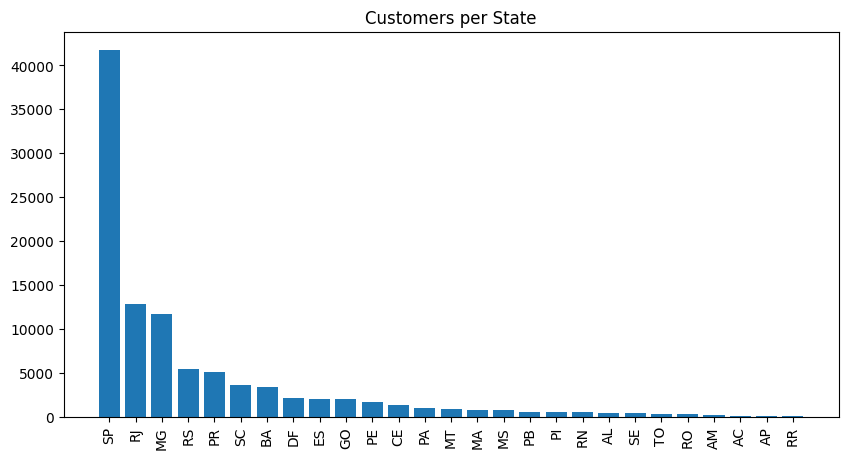

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df["customer_state"], df["customer_count"])
plt.xticks(rotation=90)
plt.title("Customers per State")
plt.show()

Calculate the number of order per month in year 2018.

In [18]:
orders = pd.DataFrame(list(db["orders"].find()))
orders.drop(columns=["_id"], inplace=True)

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

orders_2018 = orders[orders["order_purchase_timestamp"].dt.year == 2018]

orders_2018["month"] = orders_2018["order_purchase_timestamp"].dt.month_name()

df = orders_2018.groupby("month").size().reset_index(name="order_count")

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)
df = df.sort_values("month")
df

C:\Users\asus\AppData\Local\Temp\ipykernel_7576\3454111063.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_2018["month"] = orders_2018["order_purchase_timestamp"].dt.month_name()


,month,order_count
3,January,7269
2,February,6728
6,March,7211
0,April,6939
7,May,6873
5,June,6167
4,July,6292
1,August,6512
9,September,16
8,October,4


In [19]:
df = orders_2018["month"].value_counts().sort_index().reset_index()
df.columns = ["month", "order_count"]

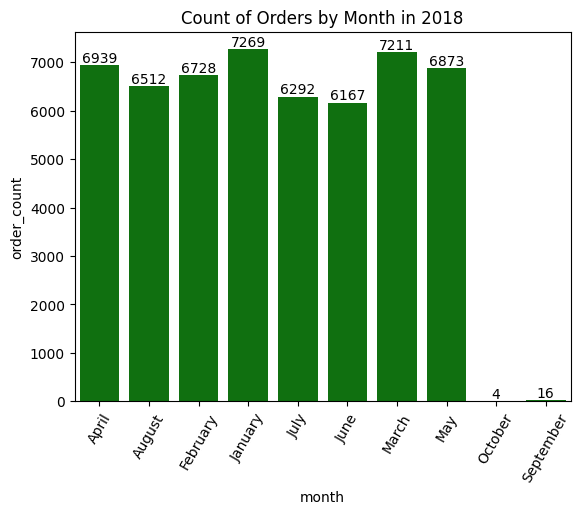

In [20]:
ax = sns.barplot(
    data=df,
    x="month",
    y="order_count",
    color="green"
)

ax.bar_label(ax.containers[0])
plt.xticks(rotation=60)
plt.title("Count of Orders by Month in 2018")
plt.show()

Find the average numbers of products per order, grouped by customer city

In [ ]:
orders = pd.DataFrame(list(db["orders"].find()))
order_items = pd.DataFrame(list(db["order_items"].find()))
customers = pd.DataFrame(list(db["customers"].find()))


orders.drop(columns=["_id"], inplace=True)
order_items.drop(columns=["_id"], inplace=True)
customers.drop(columns=["_id"], inplace=True)

order_count = order_items.groupby("order_id").size().reset_index(name="product_count")

order_customer = pd.merge(
    orders[["order_id", "customer_id"]],
    order_count,
    on="order_id"
)

df = pd.merge(
    order_customer,
    customers[["customer_id", "customer_city"]],
    on="customer_id"
)

result = df.groupby("customer_city")["product_count"] \
           .mean() \
           .round(2) \
           .reset_index(name="avg_products_per_order")

result = result.sort_values(by="avg_products_per_order", ascending=False)

result.head(10)

,customer_city,avg_products_per_order
2619,padre carvalho,7.0
907,celso ramos,6.5
756,candido godoi,6.0
1154,datas,6.0
2264,matias olimpio,5.0
2817,picarra,4.0
2395,morro de sao paulo,4.0
3821,teixeira soares,4.0
1146,curralinho,4.0
955,cidelandia,4.0


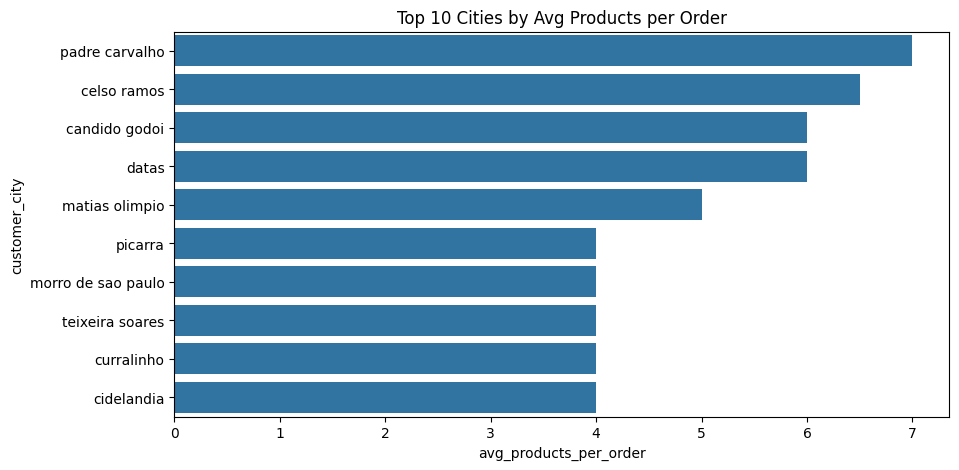

In [23]:
top10 = result.head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top10, x="avg_products_per_order", y="customer_city")
plt.title("Top 10 Cities by Avg Products per Order")
plt.show()

Calculate the % of total revenue contributed by each product category

In [ ]:
products = pd.DataFrame(list(db["products"].find()))
order_items = pd.DataFrame(list(db["order_items"].find()))
payments = pd.DataFrame(list(db["payments"].find()))


products.drop(columns=["_id"], inplace=True)
order_items.drop(columns=["_id"], inplace=True)
payments.drop(columns=["_id"], inplace=True)

df = pd.merge(
    order_items,
    products[["product_id", "product_category"]],
    on="product_id"
)

df = pd.merge(
    df,
    payments[["order_id", "payment_value"]],
    on="order_id"
)

df["category"] = df["product_category"].str.upper()

total_sales = df["payment_value"].sum()

result = df.groupby("category")["payment_value"] \
           .sum() \
           .reset_index()

result["percentage_sales"] = round(
    (result["payment_value"] / total_sales) * 100, 2
)

result = result.sort_values(by="percentage_sales", ascending=False)

result = result[["category", "percentage_sales"]]
result.head(10)

,category,percentage_sales
7,BED TABLE BATH,8.43
44,HEALTH BEAUTY,8.16
15,COMPUTER ACCESSORIES,7.81
72,WATCHES PRESENT,7.04
38,FURNITURE DECORATION,7.04
67,SPORT LEISURE,6.86
49,HOUSEWARES,5.39
4,AUTOMOTIVE,4.20
42,GARDEN TOOLS,4.13
21,COOL STUFF,3.84


In [ ]:
products = pd.DataFrame(list(db["products"].find()))
order_items = pd.DataFrame(list(db["order_items"].find()))

products.drop(columns=["_id"], inplace=True)
order_items.drop(columns=["_id"], inplace=True)

df = pd.merge(
    order_items,
    products[["product_id", "product_category"]],
    on="product_id"
)

result = df.groupby("product_category").agg(
    order_count=("product_id", "count"),
    price=("price", "mean")
).reset_index()

result["price"] = result["price"].round(2)

result.rename(columns={
    "product_category": "category"
}, inplace=True)

result.head(10)

,category,order_count,price
0,Agro Industria e Comercio,212,342.12
1,Art,209,115.80
2,Arts and Crafts,24,75.58
3,Bags Accessories,1092,128.60
4,Blu Ray DVDs,64,93.74
5,CITTE AND UPHACK FURNITURE,38,114.95
6,CONSTRUCTION SECURITY TOOLS,194,208.99
7,Casa Construcao,604,137.56
8,Christmas articles,153,57.52
9,Construction Tools Construction,929,155.73


In [26]:
category_df = df.groupby("product_category").agg(
    order_count=("product_id", "count"),
    price=("price", "mean")
).reset_index()

category_df.head()

,product_category,order_count,price
0,Agro Industria e Comercio,212,342.124858
1,Art,209,115.802105
2,Arts and Crafts,24,75.583750
3,Bags Accessories,1092,128.598883
4,Blu Ray DVDs,64,93.740469


In [27]:
arr1 = category_df["order_count"]
arr2 = category_df["price"]

np.corrcoef(arr1, arr2)

array([[ 1.        , -0.10625421],
       [-0.10625421,  1.        ]])

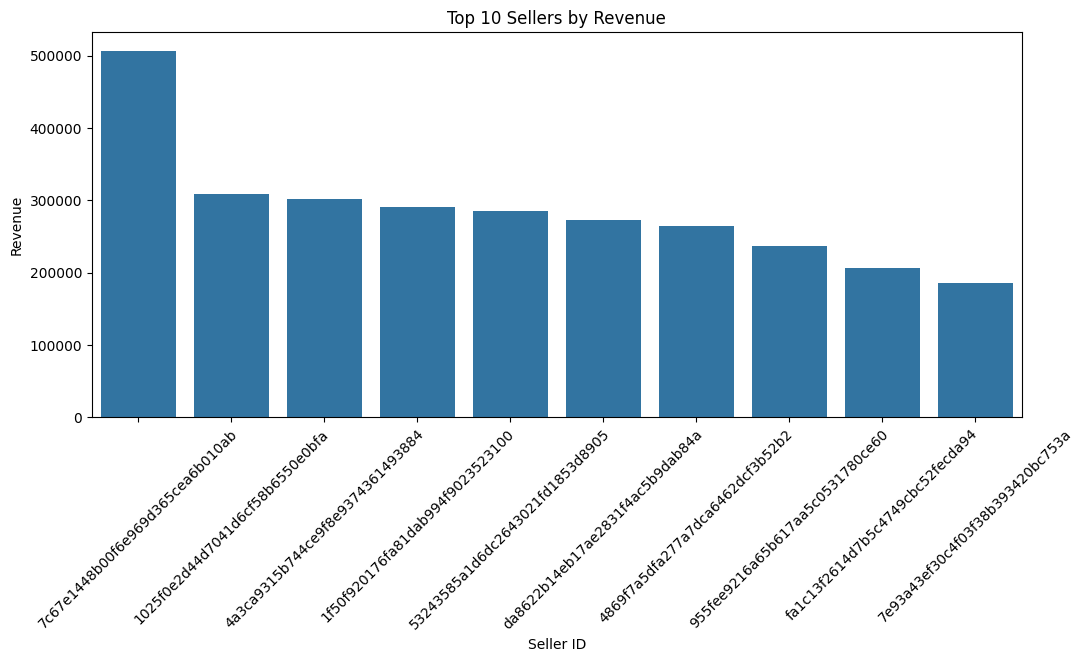

In [28]:

orders_items = pd.DataFrame(list(db["order_items"].find()))
payments = pd.DataFrame(list(db["payments"].find()))

orders_items.drop(columns=["_id"], inplace=True)
payments.drop(columns=["_id"], inplace=True)


payments_agg = payments.groupby("order_id")["payment_value"].sum().reset_index()


df = pd.merge(
    orders_items[["order_id", "seller_id"]],
    payments_agg,
    on="order_id"
)


seller_revenue = df.groupby("seller_id")["payment_value"] \
                   .sum() \
                   .reset_index(name="revenue")


seller_revenue["rank"] = seller_revenue["revenue"] \
    .rank(method="dense", ascending=False)


top_sellers = seller_revenue.sort_values(by="revenue", ascending=False).head(10)


plt.figure(figsize=(12,5))

sns.barplot(
    data=top_sellers,
    x="seller_id",
    y="revenue"
)

plt.xticks(rotation=45)
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")

plt.show()

Calculate the Moving average of order values for each customers over their order history.

In [29]:
orders = pd.DataFrame(list(db["orders"].find()))
payments = pd.DataFrame(list(db["payments"].find()))


orders.drop(columns=["_id"], inplace=True)
payments.drop(columns=["_id"], inplace=True)


df = pd.merge(
    payments[["order_id", "payment_value"]],
    orders[["order_id", "customer_id", "order_purchase_timestamp"]],
    on="order_id"
)


df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])


df = df.sort_values(by=["customer_id", "order_purchase_timestamp"])


df["mov_avg"] = df.groupby("customer_id")["payment_value"] \
                 .rolling(window=3, min_periods=1) \
                 .mean() \
                 .reset_index(level=0, drop=True)


df.rename(columns={"payment_value": "payment"}, inplace=True)


df.head(20)

,order_id,payment,customer_id,order_purchase_timestamp,mov_avg
86044,5f79b5b0931d63f1a42989eb65b9da6e,114.74,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.740000
72368,a44895d095d7e0702b6a162fa2dbeced,67.41,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.410000
84856,316a104623542e4d75189bb372bc5f8d,195.42,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.420000
91507,5825ce2e88d5346438686b0bba99e5ee,179.35,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.350000
42088,0ab7fb08086d4af9141453c91878ed7a,107.01,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.010000
2840,cd3558a10d854487b4f907e9b326a4fc,71.80,0004164d20a9e969af783496f3408652,2017-04-12 08:35:12,71.800000
80186,07f6c3baf9ac86865b60f640c4f923c6,49.40,000419c5494106c306a97b5635748086,2018-03-02 17:47:40,49.400000
46084,8c3d752c5c02227878fae49aeaddbfd7,166.59,00046a560d407e99b969756e0b10f282,2017-12-18 11:08:30,166.590000
89368,fa906f338cee30a984d0945b3832e431,85.23,00050bf6e01e69d5c0fd612f1bcfb69c,2017-09-17 16:04:44,85.230000
31370,9b961b894e797f63622137ff7eb1c1af,1255.71,000598caf2ef4117407665ac33275130,2018-08-11 12:14:35,1255.710000


calculate the cumulative sales per month for each year.

In [30]:
orders = pd.DataFrame(list(db["orders"].find()))
payments = pd.DataFrame(list(db["payments"].find()))

orders.drop(columns=["_id"], inplace=True)
payments.drop(columns=["_id"], inplace=True)

df = pd.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    payments[["order_id", "payment_value"]],
    on="order_id"
)


df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["years"] = df["order_purchase_timestamp"].dt.year
df["months"] = df["order_purchase_timestamp"].dt.month

monthly = df.groupby(["years", "months"])["payment_value"] \
            .sum() \
            .round(2) \
            .reset_index(name="payment")

monthly = monthly.sort_values(by=["years", "months"])

monthly["cumulative_sales"] = monthly["payment"].cumsum()

monthly.head(20)

,years,months,payment,cumulative_sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


Calculate the year over year groth rate of total sales.

In [31]:
orders = pd.DataFrame(list(db["orders"].find()))
payments = pd.DataFrame(list(db["payments"].find()))


orders.drop(columns=["_id"], inplace=True)
payments.drop(columns=["_id"], inplace=True)

df = pd.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    payments[["order_id", "payment_value"]],
    on="order_id"
)

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["years"] = df["order_purchase_timestamp"].dt.year

yearly = df.groupby("years")["payment_value"] \
           .sum() \
           .round(2) \
           .reset_index(name="payment")

yearly = yearly.sort_values(by="years")

yearly["prev_payment"] = yearly["payment"].shift(1)

yearly["yoy_growth"] = (
    (yearly["payment"] - yearly["prev_payment"]) 
    / yearly["prev_payment"]
) * 100

yearly["yoy_growth"] = yearly["yoy_growth"].round(2)

result = yearly[["years", "yoy_growth"]]

result

,years,yoy_growth
0,2016,NaN
1,2017,12112.7
2,2018,20.0


Calculate the retention rate of customer, defined as the % of customers who make anaother
purchase within 6 months of their first purchase.

In [32]:
orders = pd.DataFrame(list(db["orders"].find()))
customers = pd.DataFrame(list(db["customers"].find()))

orders.drop(columns=["_id"], inplace=True)
customers.drop(columns=["_id"], inplace=True)

df = pd.merge(orders, customers, on="customer_id")

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

first_order = df.groupby("customer_unique_id")["order_purchase_timestamp"] \
                .min().reset_index(name="first_order")

df = pd.merge(df, first_order, on="customer_unique_id")


df_filtered = df[
    (df["order_purchase_timestamp"] > df["first_order"]) &
    (df["order_purchase_timestamp"] <= df["first_order"] + pd.DateOffset(months=6))
]

repeat_customers = df_filtered["customer_unique_id"].nunique()
total_customers = df["customer_unique_id"].nunique()

retention_rate = (repeat_customers / total_customers) * 100

print("Repeat Customers:", repeat_customers)
print("Total Customers:", total_customers)
print("Retention Rate (%):", round(retention_rate, 2))

Repeat Customers: 2234
Total Customers: 96096
Retention Rate (%): 2.32


Identify top 3 customers who spent the most money in each year.

In [33]:
orders = pd.DataFrame(list(db["orders"].find()))
payments = pd.DataFrame(list(db["payments"].find()))
customers = pd.DataFrame(list(db["customers"].find()))


orders.drop(columns=["_id"], inplace=True)
payments.drop(columns=["_id"], inplace=True)
customers.drop(columns=["_id"], inplace=True)

df = orders.merge(payments, on="order_id") \
           .merge(customers, on="customer_id")

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["year"] = df["order_purchase_timestamp"].dt.year

grouped = df.groupby(["year", "customer_unique_id"])["payment_value"] \
            .sum().reset_index(name="payment")

grouped["rank"] = grouped.groupby("year")["payment"] \
                         .rank(method="dense", ascending=False)

top3 = grouped[grouped["rank"] <= 3]

top3.sort_values(["year", "rank"])

,year,customer_unique_id,payment,rank
319,2016,fdaa290acb9eeacb66fa7f979baa6803,1423.55,1.0
145,2016,753bc5d6efa9e49a03e34cf521a9e124,1400.74,2.0
234,2016,b92a2e5e8a6eabcc80882c7d68b2c70b,1227.78,3.0
2075,2017,0a0a92112bd4c708ca5fde585afaa872,13664.08,1.0
37662,2017,da122df9eeddfedc1dc1f5349a1a690c,7571.63,2.0
38033,2017,dc4802a71eae9be1dd28f5d788ceb526,6929.31,3.0
58553,2018,46450c74a0d8c5ca9395da1daac6c120,9553.02,1.0
68456,2018,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,2.0
58410,2018,459bef486812aa25204be022145caa62,6922.21,3.0
